In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('../data/transaction_data.xlsx')

shape_log = []  # stores each checkpoint as a dict

def log_shape(df, label):
    """Log current row/column count with a descriptive label."""
    shape_log.append({
        'step'   : label,
        'rows'   : len(df),
        'columns': df.shape[1]
    })
    print(f"[{label}] rows: {len(df):,}  |  columns: {df.shape[1]}")

log_shape(df, "01 - raw load")

[01 - raw load] rows: 264,836  |  columns: 8


In [2]:
display(df.head(10))

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [3]:
df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
display(df.head())

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_name,prod_qty,tot_sales
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [6]:
df['date'] = pd.to_datetime(df['date'],unit='D', origin='1899-12-30')
display(df.head())

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_name,prod_qty,tot_sales
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [7]:
df.describe(include="number")

,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_qty,tot_sales
count,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


**prod_qty (200) and tot_sales (650) have obvious outliers that are worth digging into**

In [8]:
outlier = df.loc[df['prod_qty']==200]
print(outlier)

            date  store_nbr  lylty_card_nbr  txn_id  prod_nbr  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              prod_name  prod_qty  tot_sales  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


this could be a valid wholesale transaction
*worth noting, but don't drop from the dataset just yet*

In [9]:
#looking at the summary stats without the outlier

df.loc[df['lylty_card_nbr']!= 226000].describe(include="number")

,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_qty,tot_sales
count,264834.000000,2.648340e+05,2.648340e+05,264834.000000,264834.000000,264834.000000
mean,135.079423,1.355488e+05,1.351576e+05,56.583554,1.905813,7.299346
std,76.784063,8.057990e+04,7.813292e+04,32.826444,0.343436,2.527241
min,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,70.000000,7.002100e+04,6.760050e+04,28.000000,2.000000,5.400000
50%,130.000000,1.303570e+05,1.351365e+05,56.000000,2.000000,7.400000
75%,203.000000,2.030940e+05,2.026998e+05,85.000000,2.000000,9.200000
max,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000


In [10]:
# create a clean product name column for easier brand and flavor extraction
df["clean_prod_name"] = df["prod_name"].str.lower().str.replace(r"[^a-z0-9\s]", "", regex=True).str.strip()
df[["prod_name", "clean_prod_name"]].head()

log_shape(df, "02 - included a clean product column")
df

[02 - included a clean product column] rows: 264,836  |  columns: 9


,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_name,prod_qty,tot_sales,clean_prod_name
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,natural chip compny seasalt175g
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,ccs nacho cheese 175g
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,smiths crinkle cut chips chicken 170g
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,smiths chip thinly screamonion 175g
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,kettle tortilla chpshnyjlpno chili 150g
...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,kettle sweet chilli and sour cream 175g
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,tostitos splash of lime 175g
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,doritos mexicana 170g
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,doritos corn chip mexican jalapeno 150g


In [11]:
df["clean_prod_name"] = (
    df["prod_name"]
    .str.lower()

    # 1. Insert space between letters and numbers
    .str.replace(r"([a-z])(\d)", r"\1 \2", regex=True)
    .str.replace(r"(\d)([a-z])", r"\1 \2", regex=True)

    # 2. Remove special characters
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)

    # 3. Normalize multiple spaces
    .str.replace(r"\s+", " ", regex=True)

    # 4. Trim
    .str.strip()
)

df[["prod_name", "clean_prod_name"]].head(10)

,prod_name,clean_prod_name
0,Natural Chip Compny SeaSalt175g,natural chip compny seasalt 175 g
1,CCs Nacho Cheese 175g,ccs nacho cheese 175 g
2,Smiths Crinkle Cut Chips Chicken 170g,smiths crinkle cut chips chicken 170 g
3,Smiths Chip Thinly S/Cream&Onion 175g,smiths chip thinly s cream onion 175 g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,kettle tortilla chpshny jlpno chili 150 g
5,Old El Paso Salsa Dip Tomato Mild 300g,old el paso salsa dip tomato mild 300 g
6,Smiths Crinkle Chips Salt & Vinegar 330g,smiths crinkle chips salt vinegar 330 g
7,Grain Waves Sweet Chilli 210g,grain waves sweet chilli 210 g
8,Doritos Corn Chip Mexican Jalapeno 150g,doritos corn chip mexican jalapeno 150 g
9,Grain Waves Sour Cream&Chives 210G,grain waves sour cream chives 210 g


In [12]:
df["net_weight"] = df["clean_prod_name"].str.extract(
    r"(\d{2,3})\s+g\b",
    expand=False
)
#convert to numeric value
df["net_weight"] = pd.to_numeric(df["net_weight"])

log_shape(df, "03 created a net_weight column extracted from clean_prod_name")

df[["prod_name", "clean_prod_name", "net_weight"]].head(10)

[03 created a net_weight column extracted from clean_prod_name] rows: 264,836  |  columns: 10


,prod_name,clean_prod_name,net_weight
0,Natural Chip Compny SeaSalt175g,natural chip compny seasalt 175 g,175
1,CCs Nacho Cheese 175g,ccs nacho cheese 175 g,175
2,Smiths Crinkle Cut Chips Chicken 170g,smiths crinkle cut chips chicken 170 g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,smiths chip thinly s cream onion 175 g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,kettle tortilla chpshny jlpno chili 150 g,150
5,Old El Paso Salsa Dip Tomato Mild 300g,old el paso salsa dip tomato mild 300 g,300
6,Smiths Crinkle Chips Salt & Vinegar 330g,smiths crinkle chips salt vinegar 330 g,330
7,Grain Waves Sweet Chilli 210g,grain waves sweet chilli 210 g,210
8,Doritos Corn Chip Mexican Jalapeno 150g,doritos corn chip mexican jalapeno 150 g,150
9,Grain Waves Sour Cream&Chives 210G,grain waves sour cream chives 210 g,210


In [13]:
# return net_weight entries that contain 'g' to double-check the extraction

df.loc[pd.to_numeric(df["net_weight"], errors="coerce").isna()]

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_name,prod_qty,tot_sales,clean_prod_name,net_weight


In [14]:
# list the most common first words in the clean product name to identify brands
first_words = df["clean_prod_name"].str.split().str[0]
first_word_counts = first_words.value_counts()

first_word_counts.head(50)  # display the top 50 most common first words

clean_prod_name
kettle        41288
smiths        28860
pringles      25102
doritos       24962
thins         14075
rrd           11894
infuzions     11057
ww            10320
cobs           9693
tostitos       9471
twisties       9454
old            9324
tyrrells       6442
grain          6272
natural        6050
red            5885
cheezels       4603
ccs            4551
woolworths     4437
dorito         3185
infzns         3144
smith          2963
cheetos        2927
snbts          1576
burger         1564
grnwves        1468
sunbites       1432
ncc            1419
french         1418
Name: count, dtype: int64

In [15]:
brand_map = {
    # Unambiguous single-token brands
    "kettle"    : "Kettle",
    "smiths"    : "Smith's",
    "smith"     : "Smith's",      # abbreviated variant
    "pringles"  : "Pringles",
    "doritos"   : "Doritos",
    "dorito"    : "Doritos",      # abbreviated variant
    "thins"     : "Thins",
    "infuzions" : "Infuzions",
    "infzns"    : "Infuzions",    # abbreviated variant
    "ww"        : "Woolworths",
    "woolworths": "Woolworths",
    "cobs"      : "Cobs",
    "tostitos"  : "Tostitos",
    "twisties"  : "Twisties",
    "tyrrells"  : "Tyrrells",
    "cheezels"  : "Cheezels",
    "ccs"       : "CCs",          
    "cheetos"   : "Cheetos",
    "snbts"     : "Sunbites",
    "sunbites"  : "Sunbites",
}

In [16]:
def fallback_brand(text):
    text = str(text)

    # Multi-word brand names — checked by substring, not first token
    if "red rock" in text or "rrd" in text:
        return "Red Rock Deli"
    if "grain waves" in text or "grnwves" in text:
        return "Grain Waves"
    if "natural chip" in text or "ncc" in text:
        return "Natural Chip Company"
    if "burger rings" in text:
        return "Burger Rings"
    if "french fries" in text:
        return "French Fries"

    return "Unknown"

In [17]:
#apply two-pass logic

def get_primary_brand(text):
    tokens = str(text).split()
    for t in tokens:
        if t in brand_map:
            return brand_map[t]
    return "Unknown"

df["brand"] = df["clean_prod_name"].apply(get_primary_brand)

# Second pass: fill remaining Unknowns using fallback substring matching
mask = df["brand"] == "Unknown"
df.loc[mask, "brand"] = df.loc[mask, "clean_prod_name"].apply(fallback_brand)

log_shape(df, "04 created a brands column")

[04 created a brands column] rows: 264,836  |  columns: 11


In [18]:
unknown_df = df[df["brand"] == "Unknown"][["prod_name", "clean_prod_name", "brand"]]

print(f"Unknown brand rows: {len(unknown_df)}")

if len(unknown_df) > 0:
    print("\nSample of unresolved rows:")
    print(unknown_df["prod_name"].value_counts().head(20).to_string())

Unknown brand rows: 9324

Sample of unresolved rows:
prod_name
Old El Paso Salsa   Dip Chnky Tom Ht300g    3125
Old El Paso Salsa   Dip Tomato Med 300g     3114
Old El Paso Salsa   Dip Tomato Mild 300g    3085


these Unkown items are mostly Salsa/Dip products that are out of scope for our purpose. 

In [19]:
df_salsa_dip = df[df["clean_prod_name"].str.contains(
    "salsa|dip",
    case=False,
    na=False
)].drop(columns=["prod_name"]).copy()

df = df[~df["clean_prod_name"].str.contains(
    "salsa|dip",
    case=False,
    na=False
)].drop(columns=["prod_name"]).copy()

display(df.head(10))

log_shape(df, "05 dropped salsa/dip products; dropped old prod_name column")

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_qty,tot_sales,clean_prod_name,net_weight,brand
0,2018-10-17,1,1000,1,5,2,6.0,natural chip compny seasalt 175 g,175,Natural Chip Company
1,2019-05-14,1,1307,348,66,3,6.3,ccs nacho cheese 175 g,175,CCs
2,2019-05-20,1,1343,383,61,2,2.9,smiths crinkle cut chips chicken 170 g,170,Smith's
3,2018-08-17,2,2373,974,69,5,15.0,smiths chip thinly s cream onion 175 g,175,Smith's
4,2018-08-18,2,2426,1038,108,3,13.8,kettle tortilla chpshny jlpno chili 150 g,150,Kettle
6,2019-05-16,4,4149,3333,16,1,5.7,smiths crinkle chips salt vinegar 330 g,330,Smith's
7,2019-05-16,4,4196,3539,24,1,3.6,grain waves sweet chilli 210 g,210,Grain Waves
8,2018-08-20,5,5026,4525,42,1,3.9,doritos corn chip mexican jalapeno 150 g,150,Doritos
9,2018-08-18,7,7150,6900,52,2,7.2,grain waves sour cream chives 210 g,210,Grain Waves
10,2019-05-17,7,7215,7176,16,1,5.7,smiths crinkle chips salt vinegar 330 g,330,Smith's


[05 dropped salsa/dip products; dropped old prod_name column] rows: 245,304  |  columns: 10


In [20]:
display(df.loc[df["brand"]=='Unknown'])

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_qty,tot_sales,clean_prod_name,net_weight,brand


**no more Unknown brands**

In [21]:
#quick glance at the brands

df["brand"].unique().tolist()

['Natural Chip Company',
 'CCs',
 "Smith's",
 'Kettle',
 'Grain Waves',
 'Doritos',
 'Twisties',
 'Woolworths',
 'Thins',
 'Burger Rings',
 'Cheezels',
 'Infuzions',
 'Red Rock Deli',
 'Pringles',
 'Tyrrells',
 'Cobs',
 'French Fries',
 'Tostitos',
 'Cheetos',
 'Sunbites']

**looks good! let's proceed with familiarizing with the net_weight column**

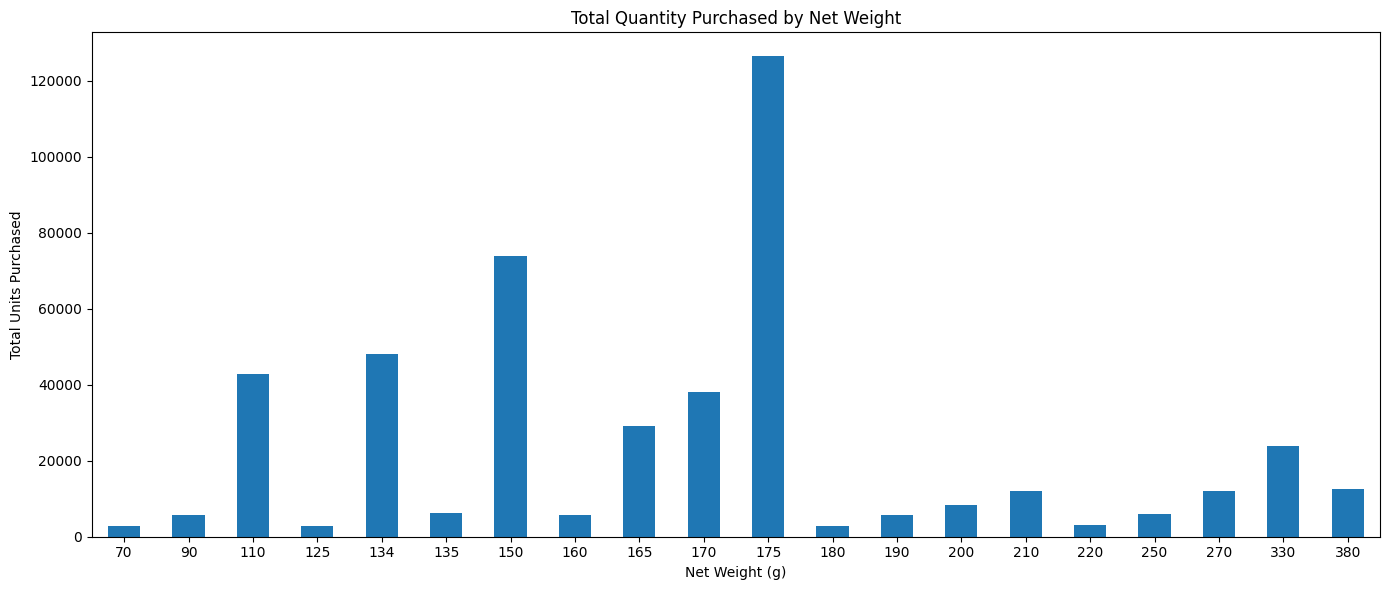

In [22]:
df.groupby("net_weight")["prod_qty"].sum().sort_index().plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Total Quantity Purchased by Net Weight")
plt.xlabel("Net Weight (g)")
plt.ylabel("Total Units Purchased")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

let's inspect whether the outlier will significantly affect the graph

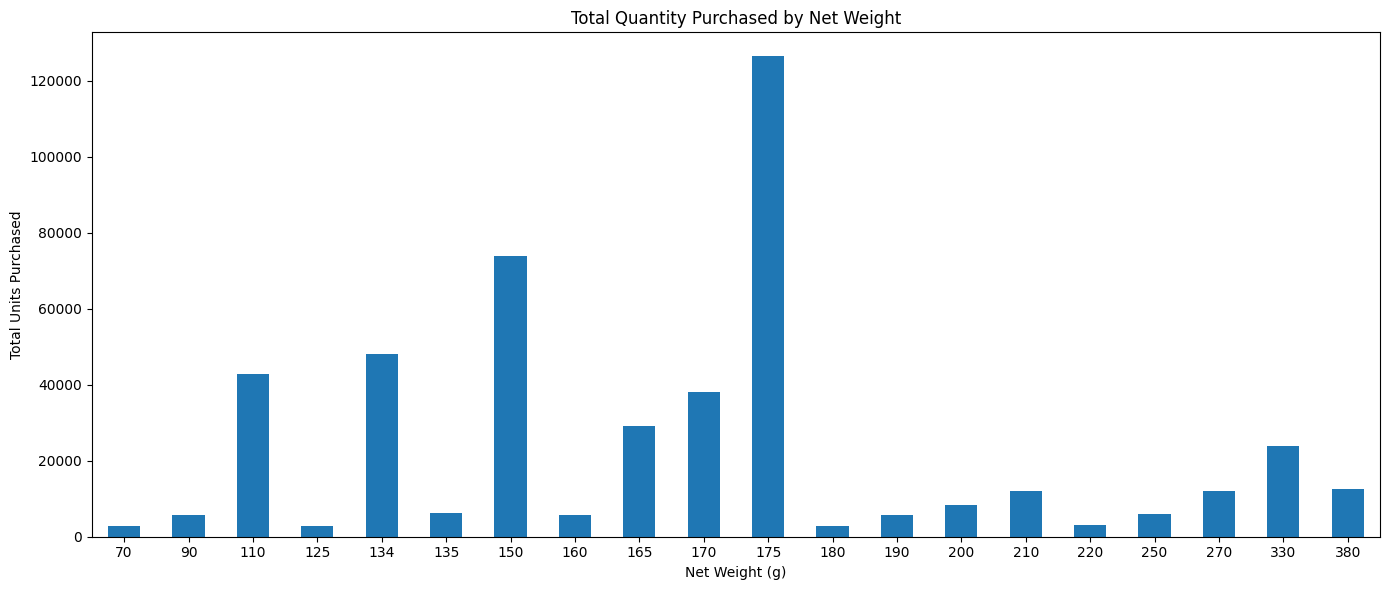

In [23]:
df_no_outlier = df.loc[df["lylty_card_nbr"] != 226000]

df.groupby("net_weight")["prod_qty"].sum().sort_index().plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Total Quantity Purchased by Net Weight")
plt.xlabel("Net Weight (g)")
plt.ylabel("Total Units Purchased")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*a subtle dip on the 380 pack size column* 

# moving on to the date column

In [24]:
# count the number of transactions per date

transactions_per_date = df.groupby("date").size()
print(transactions_per_date)

date
2018-07-01    657
2018-07-02    647
2018-07-03    667
2018-07-04    667
2018-07-05    654
             ... 
2019-06-26    657
2019-06-27    666
2019-06-28    670
2019-06-29    695
2019-06-30    698
Length: 364, dtype: int64


only 364 days covered; let me zoom in on this

<Axes: >

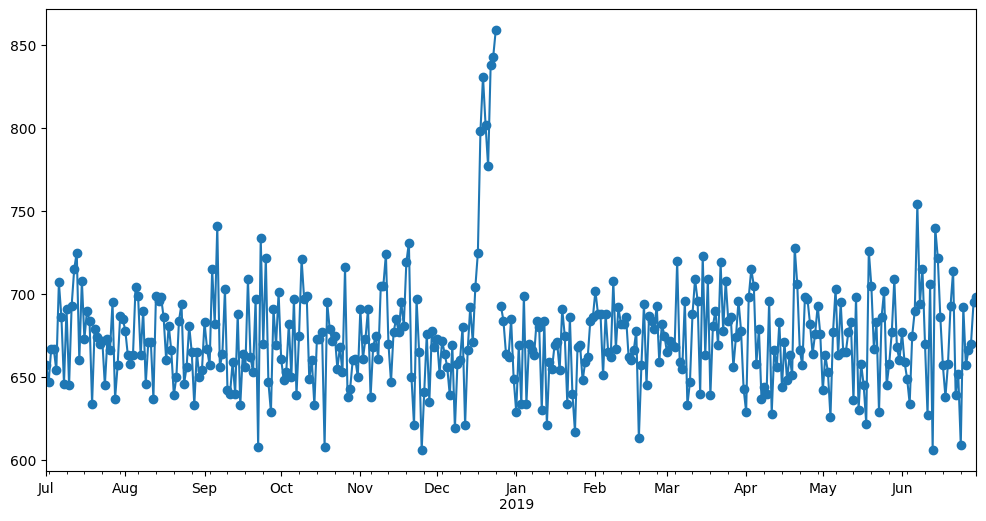

In [25]:
# plot the number of transactions per date as a line chart

transactions_per_date.reindex(
    pd.date_range(
        transactions_per_date.index.min(),
        transactions_per_date.index.max(),
        freq="D"
    )
).plot(kind="line", marker="o", figsize=(12, 6))

*a visible break between the latter part of December and early January; let's dig deeper*

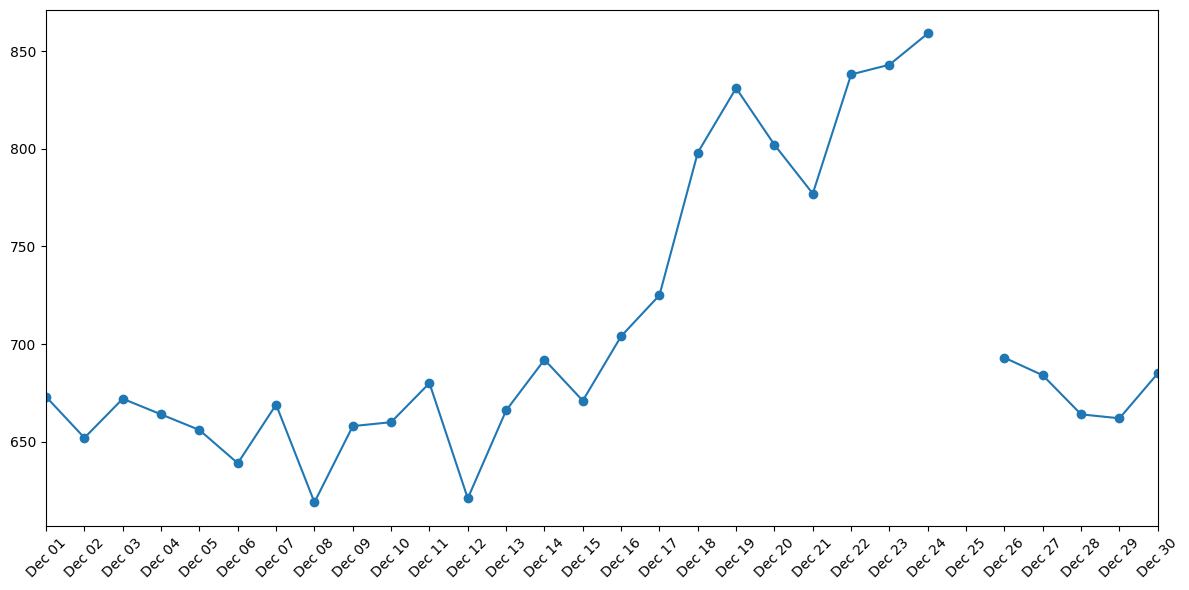

In [26]:
import matplotlib.dates as mdates

df_dec = df[df["date"].dt.month == 12].copy()

transactions_per_date_dec = (
    df_dec.groupby(df_dec["date"].dt.normalize()).size()
)

full_days = pd.date_range("2018-12-01", "2018-12-30", freq="D")

ax = transactions_per_date_dec.reindex(full_days).plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*a normal upwards trend towards the Holiday* with its highest peak at the 24th
no recorded transaction on the 25th as the stores are closed; makes sense!

In [27]:
# ── CLEANING SUMMARY ──────────────────────────────────────────────────────────
print(pd.DataFrame(shape_log).to_string(index=False))

                                                         step   rows  columns
                                                01 - raw load 264836        8
                         02 - included a clean product column 264836        9
03 created a net_weight column extracted from clean_prod_name 264836       10
                                   04 created a brands column 264836       11
  05 dropped salsa/dip products; dropped old prod_name column 245304       10


# with the cleaned and logically-sound transaction dataset, let's now look at the customer dataset

In [28]:
df_customer = pd.read_csv('../data/purchase_behavior.csv')
display(df_customer.head(10))

log_shape(df_customer, "06 raw load of customer dataset")

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


[06 raw load of customer dataset] rows: 72,637  |  columns: 3


In [29]:
df_customer.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [30]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [31]:
df_customer.columns = df_customer.columns.str.strip().str.lower()
df_customer.columns.tolist()

['lylty_card_nbr', 'lifestage', 'premium_customer']

In [32]:
# a quick overview of the population

df_customer["lifestage"].value_counts()

lifestage
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [33]:
print(df.columns.tolist())
print(df_customer.columns.tolist())

['date', 'store_nbr', 'lylty_card_nbr', 'txn_id', 'prod_nbr', 'prod_qty', 'tot_sales', 'clean_prod_name', 'net_weight', 'brand']
['lylty_card_nbr', 'lifestage', 'premium_customer']


In [34]:
df_complete = pd.merge(df, df_customer, on='lylty_card_nbr')

display(df_complete.head(10))

log_shape(df_complete, "07 merged transactions with customer datasets")

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_qty,tot_sales,clean_prod_name,net_weight,brand,lifestage,premium_customer
0,2018-10-17,1,1000,1,5,2,6.0,natural chip compny seasalt 175 g,175,Natural Chip Company,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,3,6.3,ccs nacho cheese 175 g,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,2,2.9,smiths crinkle cut chips chicken 170 g,170,Smith's,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,5,15.0,smiths chip thinly s cream onion 175 g,175,Smith's,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,3,13.8,kettle tortilla chpshny jlpno chili 150 g,150,Kettle,MIDAGE SINGLES/COUPLES,Budget
5,2019-05-16,4,4149,3333,16,1,5.7,smiths crinkle chips salt vinegar 330 g,330,Smith's,MIDAGE SINGLES/COUPLES,Budget
6,2019-05-16,4,4196,3539,24,1,3.6,grain waves sweet chilli 210 g,210,Grain Waves,MIDAGE SINGLES/COUPLES,Budget
7,2018-08-20,5,5026,4525,42,1,3.9,doritos corn chip mexican jalapeno 150 g,150,Doritos,MIDAGE SINGLES/COUPLES,Budget
8,2018-08-18,7,7150,6900,52,2,7.2,grain waves sour cream chives 210 g,210,Grain Waves,MIDAGE SINGLES/COUPLES,Budget
9,2019-05-17,7,7215,7176,16,1,5.7,smiths crinkle chips salt vinegar 330 g,330,Smith's,MIDAGE SINGLES/COUPLES,Budget


[07 merged transactions with customer datasets] rows: 245,304  |  columns: 12


In [35]:
df_complete['premium_customer'].isnull().sum()

np.int64(0)

In [36]:
df_complete['lifestage'].isnull().sum()

np.int64(0)

*Did every customer from the customer dataset successfully find a match after the merge?*

In [37]:
customers_total = set(df_customer["lylty_card_nbr"])
customers_merged = set(df_complete["lylty_card_nbr"])

customers_without_transactions = customers_total - customers_merged

print(f"Customers in customer dataset: {len(customers_total)}")
print(f"Customers after merge:         {len(customers_merged)}")
print(f"Customers with no transactions: {len(customers_without_transactions)}")

Customers in customer dataset: 72637
Customers after merge:         71186
Customers with no transactions: 1451


**1451** Customers are dropped from the merge; this could either mean:

*no purchases, or;* <br>
*purchased non-chip products*

In [38]:
#take a small sample of the customers with no transaction data

missing_customers = df_customer[
    df_customer["lylty_card_nbr"].isin(customers_without_transactions)
]

missing_customers.head(10)

,lylty_card_nbr,lifestage,premium_customer
21,1028,YOUNG SINGLES/COUPLES,Budget
48,1074,RETIREES,Budget
49,1076,YOUNG SINGLES/COUPLES,Budget
78,1117,OLDER SINGLES/COUPLES,Mainstream
90,1137,MIDAGE SINGLES/COUPLES,Premium
95,1143,OLDER FAMILIES,Budget
100,1152,RETIREES,Budget
111,1170,OLDER FAMILIES,Mainstream
112,1171,RETIREES,Mainstream
165,1248,RETIREES,Budget


In [39]:
matched_customers = pd.merge(
    missing_customers,
    df_salsa_dip,
    on="lylty_card_nbr",
    how="inner"
)

matched_customers.head(10)


,lylty_card_nbr,lifestage,premium_customer,date,store_nbr,txn_id,prod_nbr,prod_qty,tot_sales,clean_prod_name,net_weight,brand
0,1028,YOUNG SINGLES/COUPLES,Budget,2019-06-05,1,36,64,1,2.7,red rock deli sr salsa mzzrlla 150 g,150,Red Rock Deli
1,1074,RETIREES,Budget,2019-01-18,1,86,107,1,2.6,smiths crinkle cut french oniondip 150 g,150,Smith's
2,1076,YOUNG SINGLES/COUPLES,Budget,2019-05-16,1,87,107,1,2.6,smiths crinkle cut french oniondip 150 g,150,Smith's
3,1117,OLDER SINGLES/COUPLES,Mainstream,2019-03-05,1,139,57,1,5.1,old el paso salsa dip tomato mild 300 g,300,Unknown
4,1137,MIDAGE SINGLES/COUPLES,Premium,2018-09-03,1,158,41,1,2.6,doritos salsa mild 300 g,300,Doritos
5,1143,OLDER FAMILIES,Budget,2018-08-26,1,166,41,1,2.6,doritos salsa mild 300 g,300,Doritos
6,1152,RETIREES,Budget,2019-03-08,1,177,101,1,2.6,doritos salsa medium 300 g,300,Doritos
7,1170,OLDER FAMILIES,Mainstream,2019-02-09,1,196,65,2,10.2,old el paso salsa dip chnky tom ht 300 g,300,Unknown
8,1171,RETIREES,Mainstream,2018-10-14,1,197,39,1,2.6,smiths crinkle cut tomato salsa 150 g,150,Smith's
9,1248,RETIREES,Budget,2019-05-28,1,285,107,1,2.6,smiths crinkle cut french oniondip 150 g,150,Smith's


In [40]:
print(
    f"Missing customers found in df_salsa_dip: "
    f"{matched_customers['lylty_card_nbr'].nunique()}"
)

Missing customers found in df_salsa_dip: 1451


**now it's clear that all omitted data from the merge are all non-chip products**

In [41]:
# Check if outlier survived the merge
print(df_complete['lylty_card_nbr'].eq(226000).sum())  # returns 0 if already gone

# Check the merge itself — how many rows were lost
print(f"transaction rows:    {len(df)}")
print(f"merged rows:   {len(df_complete)}")
print(f"dropped rows:  {len(df) - len(df_complete)}")

2
transaction rows:    245304
merged rows:   245304
dropped rows:  0


In [42]:
display(df_complete.head(10))

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_qty,tot_sales,clean_prod_name,net_weight,brand,lifestage,premium_customer
0,2018-10-17,1,1000,1,5,2,6.0,natural chip compny seasalt 175 g,175,Natural Chip Company,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,3,6.3,ccs nacho cheese 175 g,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,2,2.9,smiths crinkle cut chips chicken 170 g,170,Smith's,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,5,15.0,smiths chip thinly s cream onion 175 g,175,Smith's,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,3,13.8,kettle tortilla chpshny jlpno chili 150 g,150,Kettle,MIDAGE SINGLES/COUPLES,Budget
5,2019-05-16,4,4149,3333,16,1,5.7,smiths crinkle chips salt vinegar 330 g,330,Smith's,MIDAGE SINGLES/COUPLES,Budget
6,2019-05-16,4,4196,3539,24,1,3.6,grain waves sweet chilli 210 g,210,Grain Waves,MIDAGE SINGLES/COUPLES,Budget
7,2018-08-20,5,5026,4525,42,1,3.9,doritos corn chip mexican jalapeno 150 g,150,Doritos,MIDAGE SINGLES/COUPLES,Budget
8,2018-08-18,7,7150,6900,52,2,7.2,grain waves sour cream chives 210 g,210,Grain Waves,MIDAGE SINGLES/COUPLES,Budget
9,2019-05-17,7,7215,7176,16,1,5.7,smiths crinkle chips salt vinegar 330 g,330,Smith's,MIDAGE SINGLES/COUPLES,Budget


In [43]:
# ── CLEANING SUMMARY ──────────────────────────────────────────────────────────
print(pd.DataFrame(shape_log).to_string(index=False))

                                                         step   rows  columns
                                                01 - raw load 264836        8
                         02 - included a clean product column 264836        9
03 created a net_weight column extracted from clean_prod_name 264836       10
                                   04 created a brands column 264836       11
  05 dropped salsa/dip products; dropped old prod_name column 245304       10
                              06 raw load of customer dataset  72637        3
                07 merged transactions with customer datasets 245304       12


# let's now head on to excel for some Data Analysis

In [44]:
#export df to csv

df_complete = df_complete.to_csv('../data/customer_transactions.csv', index=False)

from our excel analysis, noteworthy cohorts across 3 metrics are **Mainstream Young Couples** and **Older Families** <br> Let's dig deeper on these cohort's buying preferences. 

In [45]:
df_complete = pd.read_csv('../data/customer_transactions.csv')
display(df_complete.head(10))

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_qty,tot_sales,clean_prod_name,net_weight,brand,lifestage,premium_customer
0,2018-10-17,1,1000,1,5,2,6.0,natural chip compny seasalt 175 g,175,Natural Chip Company,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,3,6.3,ccs nacho cheese 175 g,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,2,2.9,smiths crinkle cut chips chicken 170 g,170,Smith's,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,5,15.0,smiths chip thinly s cream onion 175 g,175,Smith's,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,3,13.8,kettle tortilla chpshny jlpno chili 150 g,150,Kettle,MIDAGE SINGLES/COUPLES,Budget
5,2019-05-16,4,4149,3333,16,1,5.7,smiths crinkle chips salt vinegar 330 g,330,Smith's,MIDAGE SINGLES/COUPLES,Budget
6,2019-05-16,4,4196,3539,24,1,3.6,grain waves sweet chilli 210 g,210,Grain Waves,MIDAGE SINGLES/COUPLES,Budget
7,2018-08-20,5,5026,4525,42,1,3.9,doritos corn chip mexican jalapeno 150 g,150,Doritos,MIDAGE SINGLES/COUPLES,Budget
8,2018-08-18,7,7150,6900,52,2,7.2,grain waves sour cream chives 210 g,210,Grain Waves,MIDAGE SINGLES/COUPLES,Budget
9,2019-05-17,7,7215,7176,16,1,5.7,smiths crinkle chips salt vinegar 330 g,330,Smith's,MIDAGE SINGLES/COUPLES,Budget


In [46]:
# Mainstream Young Singles/Couples
segment_young = df_complete[
    (df_complete["lifestage"] == "YOUNG SINGLES/COUPLES") &
    (df_complete["premium_customer"] == "Mainstream")
]

other_young = df_complete[
    ~(
        (df_complete["lifestage"] == "YOUNG SINGLES/COUPLES") &
        (df_complete["premium_customer"] == "Mainstream")
    )
]

brand_affinity_young = pd.merge(
    (
        segment_young.groupby("brand")["prod_qty"].sum()
        / segment_young["prod_qty"].sum()
    ).rename("target_segment"),
    (
        other_young.groupby("brand")["prod_qty"].sum()
        / other_young["prod_qty"].sum()
    ).rename("other"),
    on="brand"
)

#brand affinity compared to the rest of the population

brand_affinity_young["affinity_to_brand"] = (
    brand_affinity_young["target_segment"]
    / brand_affinity_young["other"]
)

brand_affinity_young = brand_affinity_young.sort_values(
    "affinity_to_brand",
    ascending=False
)

display(brand_affinity_young)

,target_segment,other,affinity_to_brand
brand,,,
Tyrrells,0.031666,0.025822,1.226330
Twisties,0.046350,0.038068,1.217567
Doritos,0.123203,0.102511,1.201852
Kettle,0.198698,0.166389,1.194178
Tostitos,0.045574,0.038170,1.193994
Pringles,0.119850,0.101143,1.184964
Cobs,0.044798,0.039246,1.141481
Infuzions,0.064912,0.057353,1.131805
Thins,0.060590,0.057274,1.057900


In [47]:
# Older Families
segment_older = df_complete[
    df_complete["lifestage"] == "OLDER FAMILIES"
]

other_older = df_complete[
    df_complete["lifestage"] != "OLDER FAMILIES"
]

brand_affinity_older = pd.merge(
    (
        segment_older.groupby("brand")["prod_qty"].sum()
        / segment_older["prod_qty"].sum()
    ).rename("target_segment"),
    (
        other_older.groupby("brand")["prod_qty"].sum()
        / other_older["prod_qty"].sum()
    ).rename("other"),
    on="brand"
)
#brand affinity compared to the rest of the population

brand_affinity_older["affinity_to_brand"] = (
    brand_affinity_older["target_segment"]
    / brand_affinity_older["other"]
)

brand_affinity_older = brand_affinity_older.sort_values(
    "affinity_to_brand",
    ascending=False
)

display(brand_affinity_older)

,target_segment,other,affinity_to_brand
brand,,,
Burger Rings,0.007762,0.006018,1.289819
Woolworths,0.057914,0.045358,1.276842
Red Rock Deli,0.079913,0.062783,1.272837
Cheetos,0.013780,0.011360,1.213024
Natural Chip Company,0.034958,0.029023,1.204513
Sunbites,0.013746,0.011794,1.165508
CCs,0.020790,0.017839,1.165473
Smith's,0.129313,0.114438,1.129986
French Fries,0.006201,0.005519,1.123605


In [48]:
#looking at the affinity scores side-by-side

brand_affinity_compare = pd.merge(
    brand_affinity_young[["affinity_to_brand"]]
        .rename(columns={"affinity_to_brand": "young_brand_affinity"}),
    brand_affinity_older[["affinity_to_brand"]]
        .rename(columns={"affinity_to_brand": "older_brand_affinity"}),
    left_index=True,
    right_index=True,
    how="outer"
).reset_index()

brand_affinity_compare = brand_affinity_compare.sort_values(
    "young_brand_affinity",
    ascending=False
)

display(brand_affinity_compare)

,brand,young_brand_affinity,older_brand_affinity
18,Tyrrells,1.226330,0.903027
17,Twisties,1.217567,0.934911
5,Doritos,1.201852,0.929851
9,Kettle,1.194178,0.882270
16,Tostitos,1.193994,0.863177
11,Pringles,1.184964,0.901473
4,Cobs,1.141481,0.890658
8,Infuzions,1.131805,0.943261
15,Thins,1.057900,0.945399
7,Grain Waves,1.047366,0.998188


**these cohorts have contrasting brand preferences, interesting!**

with their preferred brands nailed down, let's dig deeper into the pack size of chips they usually reach out to

In [49]:
# Mainstream Young Singles/Couples
pack_affinity_young = pd.merge(
    (
        segment_young.groupby("net_weight")["prod_qty"].sum()
        / segment_young["prod_qty"].sum()
    ).rename("target_segment"),
    (
        other_young.groupby("net_weight")["prod_qty"].sum()
        / other_young["prod_qty"].sum()
    ).rename("other"),
    on="net_weight"
)

pack_affinity_young["affinity_to_pack"] = (
    pack_affinity_young["target_segment"]
    / pack_affinity_young["other"]
)

pack_affinity_young = pack_affinity_young.sort_values(
    "affinity_to_pack",
    ascending=False
)


# Older Families
pack_affinity_older = pd.merge(
    (
        segment_older.groupby("net_weight")["prod_qty"].sum()
        / segment_older["prod_qty"].sum()
    ).rename("target_segment"),
    (
        other_older.groupby("net_weight")["prod_qty"].sum()
        / other_older["prod_qty"].sum()
    ).rename("other"),
    on="net_weight"
)

pack_affinity_older["affinity_to_pack"] = (
    pack_affinity_older["target_segment"]
    / pack_affinity_older["other"]
)

pack_affinity_older = pack_affinity_older.sort_values(
    "affinity_to_pack",
    ascending=False
)

# Display results
print("=== Mainstream Young Singles/Couples ===")
display(pack_affinity_young.head(10))

print("=== Older Families ===")
display(pack_affinity_older.head(10))

=== Mainstream Young Singles/Couples ===


,target_segment,other,affinity_to_pack
net_weight,,,
270,0.031943,0.025223,1.266464
330,0.061504,0.050415,1.219960
380,0.032276,0.026639,1.211593
134,0.119850,0.101143,1.184964
110,0.106663,0.090244,1.181936
210,0.029228,0.025248,1.157651
135,0.014822,0.013141,1.127887
250,0.014406,0.012845,1.121552
170,0.081064,0.081395,0.995936


=== Older Families ===


,target_segment,other,affinity_to_pack
net_weight,,,
180,0.007466,0.005545,1.346456
220,0.007762,0.006018,1.289819
200,0.021987,0.017079,1.287400
190,0.014544,0.011560,1.258118
160,0.014065,0.011489,1.224224
70,0.006953,0.005902,1.177988
90,0.013746,0.011794,1.165508
125,0.006577,0.005660,1.161874
165,0.066759,0.060980,1.094780


Pack size preferences are drastically different. To see it clearer, I will orgranize these into tabular form with for side-by-side comparison. 

In [50]:
pack_affinity_compare = pd.merge(
    pack_affinity_young.reset_index()[["net_weight", "affinity_to_pack"]]
        .rename(columns={"affinity_to_pack": "young_affinity"}),
    pack_affinity_older.reset_index()[["net_weight", "affinity_to_pack"]]
        .rename(columns={"affinity_to_pack": "older_affinity"}),
    on="net_weight",
    how="outer"
)

pack_affinity_compare.sort_values(
    "young_affinity",
    ascending=False
)

,net_weight,young_affinity,older_affinity
17,270,1.266464,0.926203
18,330,1.219960,0.946081
19,380,1.211593,1.057991
4,134,1.184964,0.901473
2,110,1.181936,0.905519
14,210,1.157651,0.923703
5,135,1.127887,0.868752
16,250,1.121552,0.952285
9,170,0.995936,1.003837
6,150,0.976568,1.006785


the contrasting preferences are evident both in brands and pack sizes

-- mainstream young singles/couples demonstrated strong preferences for larger pack sizes that usually comes at a premium (checks out with their high Price_per_Unit)
-- Older Families heavily favored smaller to mid-size packs (relates to their higher average basket size)

In [51]:
df_complete.loc[df_complete['net_weight']==270, "brand"].unique()

array(['Twisties'], dtype=object)

In [52]:
#check if net_weight are popular due to brand

pref_Young = df_complete.loc[
    df_complete["net_weight"].isin([270, 330, 380, 134, 110])
].groupby(["net_weight", "brand"]).size().sort_values(ascending=False)

display(pref_Young)

net_weight  brand    
134         Pringles     25102
110         Infuzions    12694
            Cobs          9693
330         Smith's       6339
270         Twisties      6285
380         Smith's       3233
            Doritos       3185
330         Cheezels      3149
            Doritos       3052
dtype: int64

these are top net_weight values for Mainstream Young Singles/Couples, carrying familiar brands from their affinity list, therefore
    **pack-size affinity should not be interpreted independently of brand preference** but;

        - some of these preferences are clearly driven by flagship products (e.g. Pringles and Twisties)
        - Larger pack sizes are represented by multiple brands; meaning this cohort do prefer larger pack sizes in addition to certain brands

**Cheezels** is a standout as it's the only one with relatively low brand affinity
-- it could be favored by the cohort due to it's value proposition and large pack size

In [53]:
#compare standout net_weight and analyze brand breakdown

pref_OldFam = df_complete.loc[
    df_complete["net_weight"].isin([180, 220, 200, 190, 160, 70])
].groupby(["net_weight", "brand"]).size().sort_values(ascending=False)

display(pref_OldFam)

net_weight  brand       
200         Woolworths      4473
160         Woolworths      2970
220         Burger Rings    1564
190         Woolworths      1516
70          Infuzions       1507
190         Cheetos         1479
180         Grain Waves     1468
dtype: int64

In [54]:
# Create a product identifier
df_complete["clean_prod_name"] = (
    df_complete["brand"]
    + " "
    + df_complete["net_weight"].astype(int).astype(str)
    + "g"
)

In [55]:
product_affinity_young = pd.merge(
    (
        segment_young.groupby("clean_prod_name")["prod_qty"].sum()
        / segment_young["prod_qty"].sum()
    ).rename("target_segment"),
    (
        other_young.groupby("clean_prod_name")["prod_qty"].sum()
        / other_young["prod_qty"].sum()
    ).rename("other"),
    on="clean_prod_name"
)

product_affinity_young["affinity_to_product"] = (
    product_affinity_young["target_segment"]
    / product_affinity_young["other"]
)

product_affinity_young.sort_values(
    "affinity_to_product",
    ascending=False
)

,target_segment,other,affinity_to_product
clean_prod_name,,,
doritos corn chips cheese supreme 170 g,0.017205,0.012868,1.336982
tostitos splash of lime 175 g,0.017149,0.012998,1.319385
kettle mozzarella basil pesto 175 g,0.017343,0.013322,1.301846
twisties cheese 270 g,0.016235,0.012519,1.296856
pringles mystery flavour 134 g,0.015986,0.012389,1.290299
...,...,...,...
sunbites whlegrn crisps frch onin 90 g,0.002881,0.006023,0.478362
ww original corn chips 200 g,0.002937,0.006294,0.466581
ww d style chip sea salt 200 g,0.002854,0.006157,0.463432


In [58]:
# Create a Brand + Pack identifier
df_complete["brand_pack"] = (
    df_complete["brand"]
    + " "
    + df_complete["net_weight"].astype(int).astype(str)
    + "g"
)

# Brand + Pack affinity (Mainstream Young Singles/Couples)
brand_pack_affinity = pd.merge(
    (
        segment_young.groupby("brand_pack")["prod_qty"].sum()
        / segment_young["prod_qty"].sum()
    ).rename("target_segment"),
    (
        other_young.groupby("brand_pack")["prod_qty"].sum()
        / other_young["prod_qty"].sum()
    ).rename("other"),
    on="brand_pack"
)

brand_pack_affinity["affinity_to_brand_pack"] = (
    brand_pack_affinity["target_segment"]
    / brand_pack_affinity["other"]
)

brand_pack_affinity = (
    brand_pack_affinity
    .sort_values("affinity_to_brand_pack", ascending=False)
    .reset_index()
)

display(brand_pack_affinity)

,brand_pack,target_segment,other,affinity_to_brand_pack
0,Smith's 380g,0.016512,0.012889,1.281084
1,Twisties 270g,0.031943,0.025223,1.266464
2,Doritos 330g,0.015487,0.012266,1.262550
3,Doritos 170g,0.062945,0.050651,1.242716
4,Tyrrells 165g,0.031666,0.025822,1.226330
5,Smith's 330g,0.031002,0.025475,1.216944
6,Infuzions 110g,0.061865,0.050998,1.213068
7,Kettle 150g,0.092229,0.076587,1.204241
8,Kettle 175g,0.091647,0.076661,1.195488
9,Tostitos 175g,0.045574,0.038170,1.193994


In [59]:
def classify_affinity(score):
    if score >= 1.20:
        return "Very High"
    elif score >= 1.10:
        return "High"
    elif score >= 1.05:
        return "Moderate"
    elif score >= 0.85:
        return "Neutral"
    elif score >= 0.65:
        return "Low"
    else:
        return "Very Low"

brand_pack_affinity["affinity_category"] = (
    brand_pack_affinity["affinity_to_brand_pack"]
    .apply(classify_affinity)
)

display(brand_pack_affinity)

,brand_pack,target_segment,other,affinity_to_brand_pack,affinity_category
0,Smith's 380g,0.016512,0.012889,1.281084,Very High
1,Twisties 270g,0.031943,0.025223,1.266464,Very High
2,Doritos 330g,0.015487,0.012266,1.262550,Very High
3,Doritos 170g,0.062945,0.050651,1.242716,Very High
4,Tyrrells 165g,0.031666,0.025822,1.226330,Very High
5,Smith's 330g,0.031002,0.025475,1.216944,Very High
6,Infuzions 110g,0.061865,0.050998,1.213068,Very High
7,Kettle 150g,0.092229,0.076587,1.204241,Very High
8,Kettle 175g,0.091647,0.076661,1.195488,High
9,Tostitos 175g,0.045574,0.038170,1.193994,High


In [ ]:
# check if the Older Families segment exists

segment_older.head()

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_qty,tot_sales,clean_prod_name,net_weight,brand,lifestage,premium_customer
29740,2018-07-21,77,2330461,236777,87,1,3.8,infuzions bbq rib prawn crackers 110 g,110,Infuzions,OLDER FAMILIES,Budget
29741,2019-05-20,1,1367,424,7,1,5.7,smiths crinkle original 330 g,330,Smith's,OLDER FAMILIES,Budget
29742,2018-08-17,3,3088,1462,89,2,10.8,kettle sweet chilli and sour cream 175 g,175,Kettle,OLDER FAMILIES,Budget
29743,2018-08-14,3,3147,1698,16,1,5.7,smiths crinkle chips salt vinegar 330 g,330,Smith's,OLDER FAMILIES,Budget
29744,2019-05-16,3,3206,1979,71,1,4.3,twisties cheese burger 250 g,250,Twisties,OLDER FAMILIES,Budget


In [72]:
segment_older = df_complete[
    df_complete["lifestage"] == "OLDER FAMILIES"
].copy()

other_older = df_complete[
    df_complete["lifestage"] != "OLDER FAMILIES"
].copy()

In [73]:
segment_older["brand_pack"] = (
    segment_older["brand"]
    + " "
    + segment_older["net_weight"].astype(int).astype(str)
    + "g"
)

other_older["brand_pack"] = (
    other_older["brand"]
    + " "
    + other_older["net_weight"].astype(int).astype(str)
    + "g"
)

In [74]:
# Brand + Pack affinity (Older Families)
brand_pack_affinity_older = pd.merge(
    (
        segment_older.groupby("brand_pack")["prod_qty"].sum()
        / segment_older["prod_qty"].sum()
    ).rename("target_segment"),
    (
        other_older.groupby("brand_pack")["prod_qty"].sum()
        / other_older["prod_qty"].sum()
    ).rename("other"),
    on="brand_pack"
)

brand_pack_affinity_older["affinity_to_brand_pack"] = (
    brand_pack_affinity_older["target_segment"]
    / brand_pack_affinity_older["other"]
)

brand_pack_affinity_older = (
    brand_pack_affinity_older
    .sort_values("affinity_to_brand_pack", ascending=False)
    .reset_index()
)

display(brand_pack_affinity_older)

,brand_pack,target_segment,other,affinity_to_brand_pack
0,Grain Waves 180g,0.007466,0.005545,1.346456
1,Woolworths 190g,0.007682,0.005779,1.329412
2,Red Rock Deli 150g,0.044236,0.034142,1.295673
3,Burger Rings 220g,0.007762,0.006018,1.289819
4,Woolworths 175g,0.014179,0.011011,1.287778
5,Woolworths 200g,0.021987,0.017079,1.287400
6,Red Rock Deli 165g,0.035676,0.028642,1.245616
7,Cheetos 165g,0.006919,0.005579,1.240140
8,Smith's 175g,0.035904,0.029023,1.237109
9,Doritos 380g,0.016425,0.013324,1.232692


In [75]:
brand_pack_affinity_compare = (
    pd.merge(
        brand_pack_affinity[
            ["brand_pack", "affinity_to_brand_pack"]
        ].rename(columns={
            "affinity_to_brand_pack": "young_affinity"
        }),
        brand_pack_affinity_older[
            ["brand_pack", "affinity_to_brand_pack"]
        ].rename(columns={
            "affinity_to_brand_pack": "older_affinity"
        }),
        on="brand_pack",
        how="outer"
    )
    .fillna(0)
)

display(brand_pack_affinity_compare)

,brand_pack,young_affinity,older_affinity
0,Burger Rings 220g,0.442959,1.289819
1,CCs 175g,0.590827,1.165473
2,Cheetos 165g,0.564887,1.240140
3,Cheetos 190g,0.763641,1.186857
4,Cheezels 125g,0.497726,1.161874
5,Cheezels 330g,1.184802,0.880773
6,Cobs 110g,1.141481,0.890658
7,Doritos 150g,1.122425,0.873133
8,Doritos 170g,1.242716,0.881201
9,Doritos 330g,1.262550,0.933636


In [60]:
# Recreate segments after creating brand_pack
segment_young = df_complete[
    (df_complete["lifestage"] == "YOUNG SINGLES/COUPLES") &
    (df_complete["premium_customer"] == "Mainstream")
]

other_young = df_complete[
    ~(
        (df_complete["lifestage"] == "YOUNG SINGLES/COUPLES") &
        (df_complete["premium_customer"] == "Mainstream")
    )
]

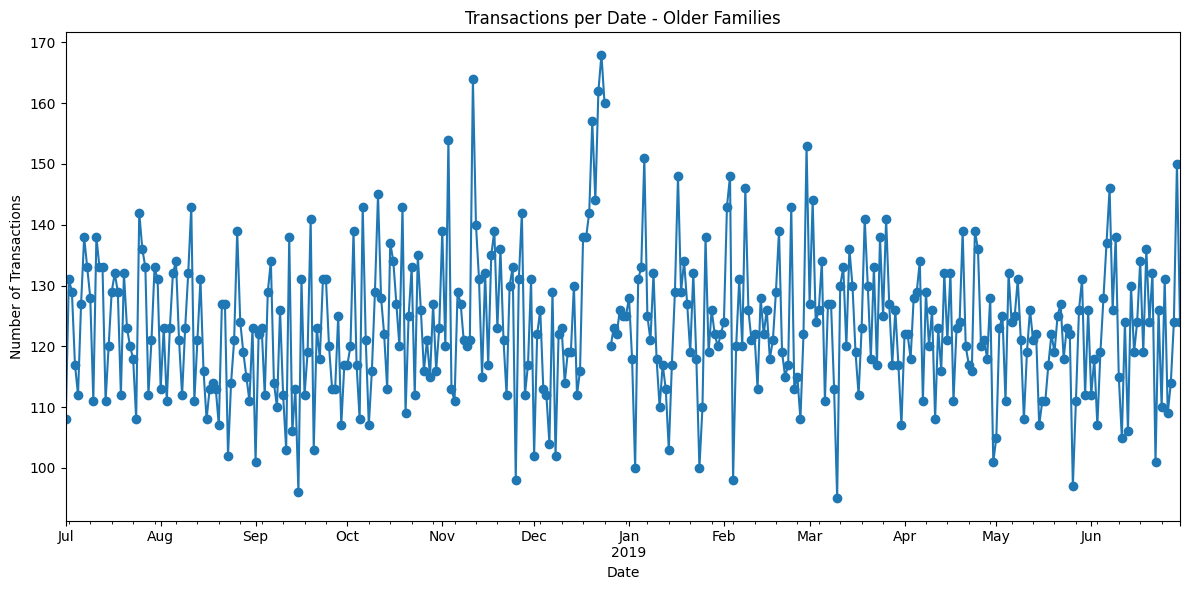

In [61]:
# Filter to Older Families
df_older = df_complete[df_complete["lifestage"] == "OLDER FAMILIES"].copy()

# Ensure date is datetime
df_older["date"] = pd.to_datetime(df_older["date"])

# Transactions per date
transactions_per_date = (
    df_older.groupby(df_older["date"].dt.normalize()).size()
)

# Plot
transactions_per_date.reindex(
    pd.date_range(
        transactions_per_date.index.min(),
        transactions_per_date.index.max(),
        freq="D"
    )
).plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Transactions per Date - Older Families")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

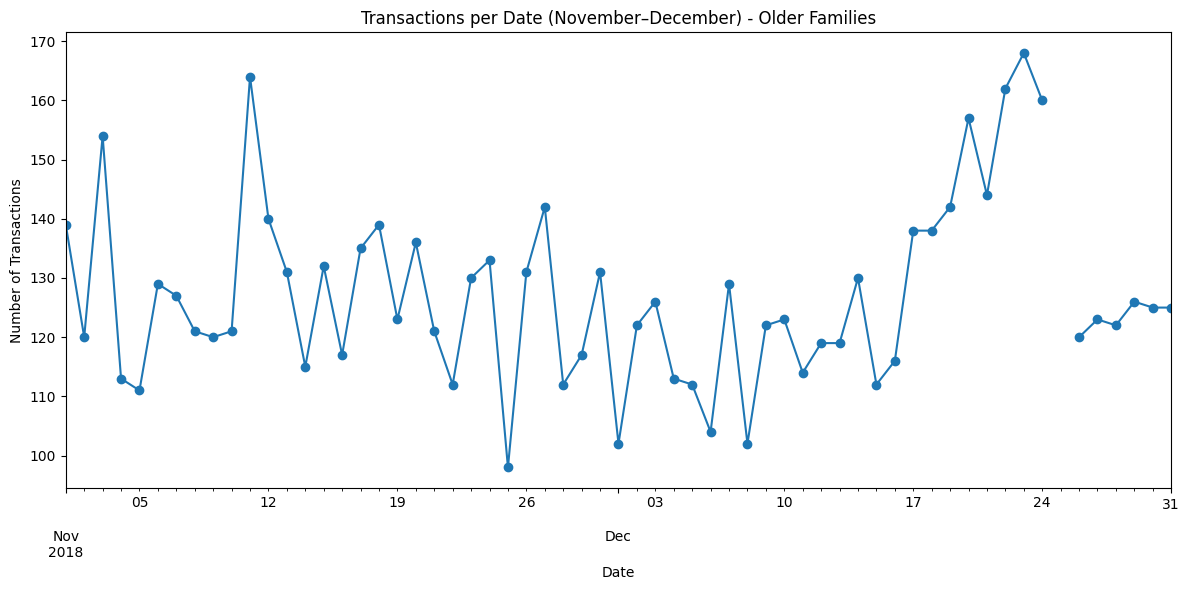

In [62]:
# Filter to Older Families
df_older = df_complete[df_complete["lifestage"] == "OLDER FAMILIES"].copy()

# Ensure date is datetime
df_older["date"] = pd.to_datetime(df_older["date"])

# Keep only November and December
df_older = df_older[df_older["date"].dt.month.isin([11, 12])]

# Transactions per date
transactions_per_date = (
    df_older.groupby(df_older["date"].dt.normalize()).size()
)

# Plot
transactions_per_date.reindex(
    pd.date_range(
        transactions_per_date.index.min(),
        transactions_per_date.index.max(),
        freq="D"
    )
).plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Transactions per Date (November–December) - Older Families")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [63]:
# Summary statistics
mean_transactions = transactions_per_date.mean()
std_transactions = transactions_per_date.std()

print(f"Average daily transactions: {mean_transactions:.2f}")
print(f"Standard deviation: {std_transactions:.2f}")

Average daily transactions: 127.15
Standard deviation: 15.42


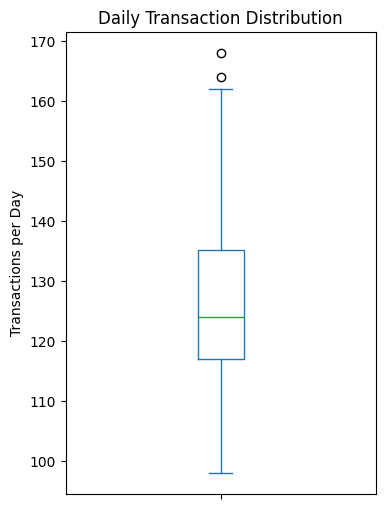

In [64]:
# Distribution of daily transaction counts
transactions_per_date.plot(kind="box", figsize=(4, 6))

plt.title("Daily Transaction Distribution")
plt.ylabel("Transactions per Day")
plt.show()

graph makes sense given the previous summary statistics

let's investigate these outliers

In [65]:
# Days with unusually high transaction counts
spikes = transactions_per_date[
    transactions_per_date > mean_transactions + 2 * std_transactions
]

display(spikes)

date
2018-11-11    164
2018-12-22    162
2018-12-23    168
2018-12-24    160
dtype: int64

Nov 11, and December 22-24 are extreme examples of days with a spike in recorded transactions

*let's look at weekly averages on the lookout for standout weeks and trends*

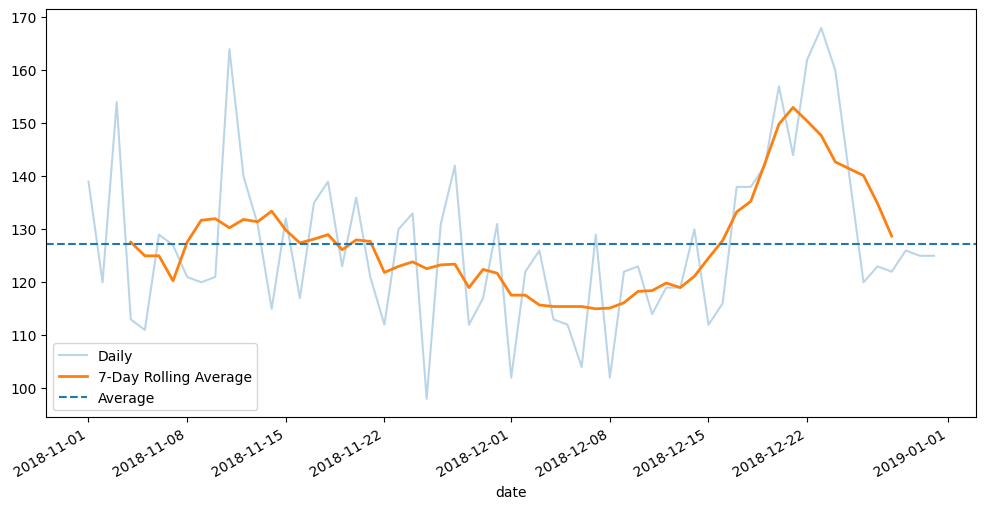

In [66]:
rolling_txn = transactions_per_date.rolling(window=7, center=True).mean()

plt.figure(figsize=(12, 6))
transactions_per_date.plot(alpha=0.3, label="Daily")
rolling_txn.plot(label="7-Day Rolling Average", linewidth=2)

plt.axhline(transactions_per_date.mean(), linestyle="--", label="Average")

plt.legend()
plt.show()

*While individual transaction spikes occurred on specific dates, the 7-day rolling average indicates that transaction volumes began increasing around mid-December, remained consistently above the annual average for approximately 10 days, and peaked during the week immediately preceding Christmas before returning to normal levels after the holiday period.*

    Nov 8–15 appears to be a moderately stronger-than-average period. The rolling average stays just above the overall mean, indicating sustained activity rather than a one-day spike.
    
    Late November to mid-December (roughly Nov 22–Dec 14): This is the clearest lull in the period. The rolling average remains consistently below the yearly average, suggesting a genuine slowdown rather than random daily variation.



In [67]:
# Baseline (year-round average daily transactions)
baseline = transactions_per_date.mean()

# Sustained holiday period (adjust dates if needed)
holiday_period = rolling_txn.loc["2018-12-15":"2018-12-24"]

holiday_avg = holiday_period.mean()

increase_pct = (
    (holiday_avg - baseline)
    / baseline
) * 100
    
print(f"Baseline average      : {baseline:.2f}")
print(f"Holiday rolling avg   : {holiday_avg:.2f}")
print(f"Increase over baseline: {increase_pct:.2f}%")

Baseline average      : 127.15
Holiday rolling avg   : 140.71
Increase over baseline: 10.67%


In [68]:
peak = rolling_txn.max()
peak_date = rolling_txn.idxmax()

peak_increase_pct = (
    (peak - baseline)
    / baseline
) * 100

print(f"Peak date             : {peak_date.strftime('%b %d, %Y')}")
print(f"Peak rolling average  : {peak:.2f}")
print(f"Peak increase         : {peak_increase_pct:.2f}%")

Peak date             : Dec 21, 2018
Peak rolling average  : 153.00
Peak increase         : 20.33%


*Transaction activity began increasing around mid-December, with the week of December 15–24 averaging 10.7% more daily transactions than the yearly baseline. At its highest point (Dec 21), the seven-day rolling average reached 20.33% above normal, indicating a sustained surge in customer purchasing leading up to Christmas rather than isolated one-day spikes.*